In [ ]:
# !python -m pip install numpy
# !python -m pip install matplotlib
# !python -m pip install opencv-python --upgrade

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import math

(2000, 2048)
(2000, 2048)


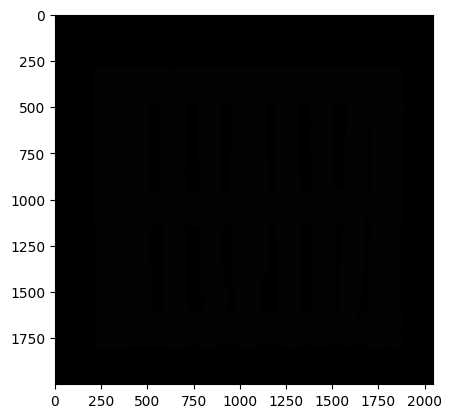

In [46]:
# image = cv2.imread("./camera_top/ORLB8_Cam4_T_B4840A_A2KV.tif", -1) #-1 significa que no trata la imagen (para que no suponga que tiene 3 capas, etc)
image = cv2.imread("./camera_top/ORLB8_Cam4_T_B4840A_A2KV.tif", -1) #-1 significa que no trata la imagen (para que no suponga que tiene 3 capas, etc)
print(image.shape)
print(image.shape)

plt.imshow(image, cmap="gray", vmin=0, vmax=2**16)

Ej 1: Generar una imagen normalizada de la imagen TIFF (cv2.normalize()), esto producirá una imagen con mayor contraste que la original.

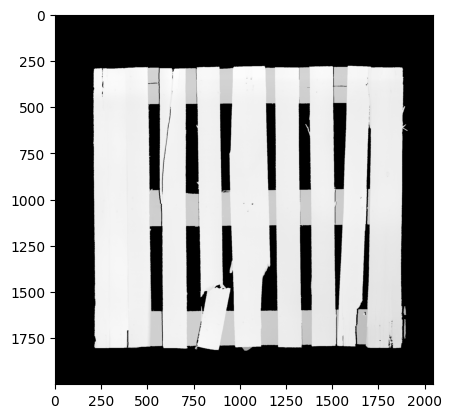

In [69]:
normalized_image = cv2.normalize(
    image, None, alpha=0, beta=2**16, norm_type=cv2.NORM_MINMAX)

plt.imshow(normalized_image, cmap="gray", vmin=0, vmax=2**16)

Ej 2: Generar dos imágenes binarias a partir de la imagen normalizada, donde en una nos quedemos con los tableros verticales y en la otra con los horizontales.

(array([[2000.,    0.,    0., ...,    0.,    0.,    0.],
        [2000.,    0.,    0., ...,    0.,    0.,    0.],
        [2000.,    0.,    0., ...,    0.,    0.,    0.],
        ...,
        [2000.,    0.,    0., ...,    0.,    0.,    0.],
        [2000.,    0.,    0., ...,    0.,    0.,    0.],
        [2000.,    0.,    0., ...,    0.,    0.,    0.]], shape=(2048, 10)),
 array([    0. ,  6553.5, 13107. , 19660.5, 26214. , 32767.5, 39321. ,
        45874.5, 52428. , 58981.5, 65535. ]),
 <a list of 2048 BarContainer objects>)

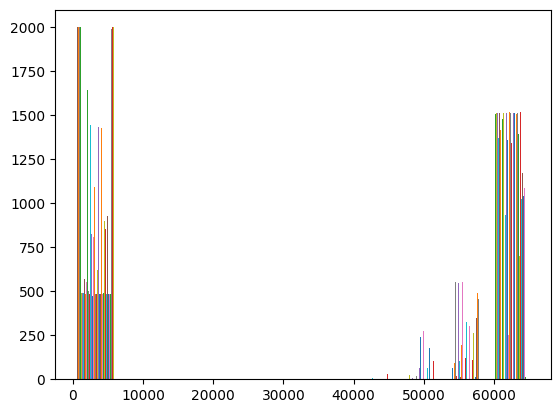

In [70]:
# histogram = cv2.calcHist(normalized_image, [0], None, [256], [0, 256])
# plt.hist(histogram, 256)

plt.hist(normalized_image)

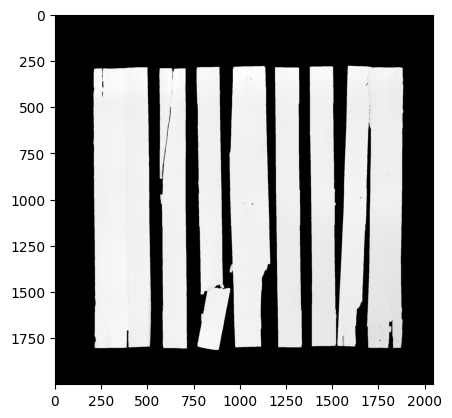

In [49]:
def binarize(image, threshhold):
    """
    Binariza una imagen en escala de grises utilizando un umbral dado.

    Parameters
    ----------
    image : numpy.ndarray
        La imagen de entrada en escala de grises.
    threshold : int
        El valor de umbral para la binarización.

    Returns
    -------
    numpy.ndarray
        La imagen binarizada.

    Notas
    -----
    Esta función convierte los píxeles de la imagen en blanco si su intensidad es mayor o igual que el umbral,
    y en negro si es menor.

    Ejemplos
    --------
    >>> img_gray = cv2.imread('imagen_gris.jpg', cv2.IMREAD_GRAYSCALE)
    >>> img_binarized = binarize(img_gray, 128)
    """
    #Empieza el codigo aqui
    width = image.shape[0]
    height = image.shape[1]
    binary_image_mayor = np.zeros((width,height))
    binary_image_menor = np.zeros((width,height))
    for x in range(width):    
        for y in range(height):
            if image[x,y] > threshhold:
                binary_image_mayor[x,y] = image[x,y]
            elif image[x,y] < threshhold:
                binary_image_menor[x,y] = image[x,y]
    #Termina el codigo aqui
    return (binary_image_menor,binary_image_mayor)


binary_image_vert = binarize(normalized_image,55000)[1]
binary_image_vert = cv2.morphologyEx(binary_image_vert, cv2.MORPH_OPEN , kernel = np.ones((5,5), dtype=np.uint8) , iterations=3)

plt.imshow(binary_image_vert,cmap='gray')

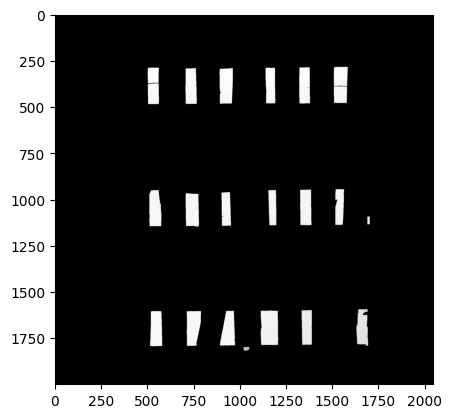

In [50]:
binary_image_horiz = binarize(normalized_image,55000)[0]
binary_image_horiz = cv2.morphologyEx(binary_image_horiz, cv2.MORPH_OPEN , kernel = np.ones((5,5), dtype=np.uint8) , iterations=3)

plt.imshow(binary_image_horiz,cmap='gray')

Ej 3: Hallar los contornos de los tableros en ambas imágenes.

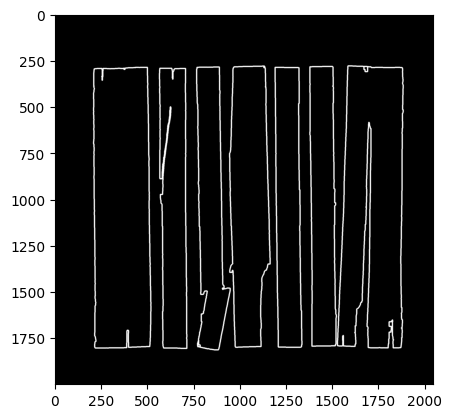

In [51]:
binary_image_vert_2 = binary_image_vert.astype(np.uint8) # esto lo convierte a una imagen de 8bits, es decir, de 0 a 255


bg_black = np.zeros((binary_image_vert_2.shape[0],binary_image_vert_2.shape[1]), np.uint8)
contours_vert, hierarchy_vert  = cv2.findContours(binary_image_vert_2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img = cv2.drawContours(bg_black, contours_vert, -1, 1, 5)
plt.imshow(img, cmap="gray")

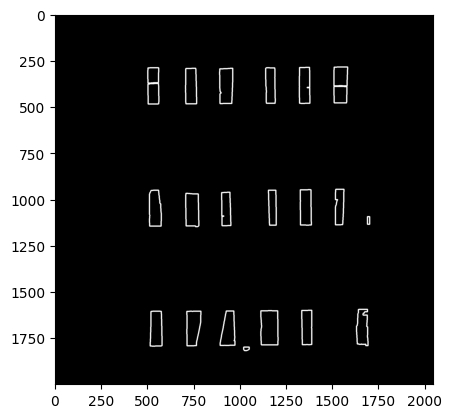

In [52]:
binary_image_horiz_2 = binary_image_horiz.astype(np.uint8) # esto lo convierte a una imagen de 8bits, es decir, de 0 a 255


bg_black = np.zeros((binary_image_horiz_2.shape[0],binary_image_horiz_2.shape[1]), np.uint8)
contours_horiz, hierarchy_horiz  = cv2.findContours(binary_image_horiz_2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img2 = cv2.drawContours(bg_black, contours_horiz, -1, 1, 5)
plt.imshow(img2, cmap="gray")

Ej 4: Contar el número de tableros.

TABLEROS VERTICALES

áreas: [197719.5, 190774.0, 446944.5, 184499.5, 189527.5, 276840.0, 439339.5]
anchuras: [149, 146, 311, 182, 144, 220, 356]
alturas [1515, 1514, 1518, 1530, 1513, 1521, 1525]
1.0 0.8186813186813187 0.9980237154150198
0.9648719524376705 0.8021978021978022 0.997364953886693
2.2604978264662816 1.7087912087912087 1.0
0.9331376015011165 1.0 1.007905138339921
0.958567566679058 0.7912087912087912 0.9967061923583662
1.400165385811718 1.2087912087912087 1.0019762845849802
2.222034245484133 1.956043956043956 1.0046113306982871
Número de tableros verticales: 9


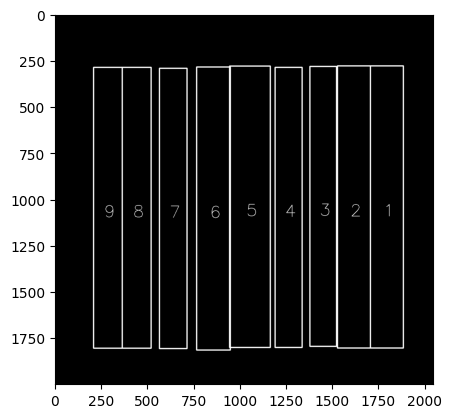

In [66]:
# Para imprimir la imagen "limpia"
contours_vert_limpia = np.zeros_like(img)
tableros_aux = []

# Calculamos características base para poder discernir si es 1 tablero o 2
areas = []
anchuras = []
alturas = []

for contorno in contours_vert:
    x, y, w, h = cv2.boundingRect(contorno)
    area = cv2.contourArea(contorno)
    areas.append(area)
    anchuras.append(w)
    alturas.append(h)

print("áreas:", areas)
print("anchuras:", anchuras)
print("alturas", alturas)

mediana_area = np.median(areas) if len(areas) > 0 else 1
mediana_ancho = np.median(anchuras) if len(anchuras) > 0 else 1
mediana_alto = np.median(alturas) if len(alturas) > 0 else 1

# Umbrales no exactos (rara vez va a llegar a ser realmente 2)
umbral_area_doble = 1.7
umbral_ancho_doble = 1.5

# Para contar los tableros. Recorremos todos los contornos para capturar posición y ratio área-área mediana
cont_vert = 0
for contorno in contours_vert:
    x, y, w, h = cv2.boundingRect(contorno)
    area = cv2.contourArea(contorno)

    ratio_area = area / mediana_area if mediana_area > 0 else 0
    ratio_ancho = w / mediana_ancho if mediana_ancho > 0 else 0
    ratio_alto = h / mediana_alto if mediana_alto > 0 else 0
    print(ratio_area, ratio_ancho, ratio_alto)

    es_doble = (ratio_ancho >= umbral_ancho_doble) or (ratio_area >= umbral_area_doble)

    if es_doble:
        cont_vert += 2
        w1 = w // 2
        w2 = w - w1
        tableros_aux.append((x, y, w1, h))
        tableros_aux.append((x + w1, y, w2, h))
    else:
        cont_vert += 1
        tableros_aux.append((x, y, w, h))

# Ordenamos los tableros en función de la X, de mayor a menor
tableros_aux = sorted(tableros_aux, key=lambda x: x[0], reverse=True)

# Actualizamos imagen limpia con los rectángulos y su numeración
i = 0
for tablero in tableros_aux:
    i += 1
    x, y, w, h = tablero
    cv2.rectangle(contours_vert_limpia, (x, y), (x + w, y + h), (255, 0, 0), 5)
    cv2.putText(
        contours_vert_limpia,
        str(i),
        (x + int(w / 2) - 20, y + int(h / 2) + 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        3,
        (255, 0, 0),
        2
    )

# Imprimimos resultado
plt.imshow(contours_vert_limpia, cmap='gray')
print("Número de tableros verticales: " + str(cont_vert))

TABLEROS HORIZONTALES

Límites cuadrantes:  702.0 1404.0 2106
Número de tableros horizontales: 3


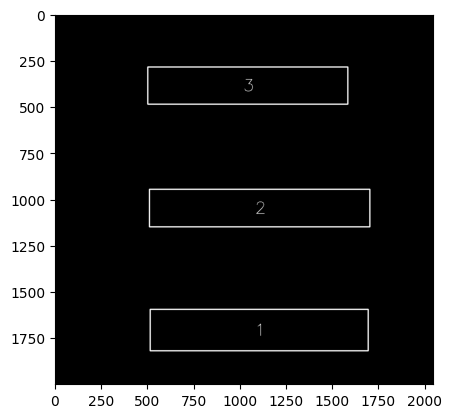

In [54]:
# "Partimos" la imagen en 3 cuadrantes. Si el palé no saliese centrado en la imagen, tendríamos problemas: lo descarto por la opción de abajo que se refiere a la parte de la imagen donde está el palé.
# quad3 = binary_image_horiz_2.shape[0] # img height
# quad2 = quad3 * 2/3
# quad1 = quad3 * 1/3
# print("Límites cuadrantes: ", quad1, quad2, quad3)

# Partimos el palé en 3 cuadrantes
minY = []
maxY = []
for contorno in contours_horiz:
    x, y, w, h = cv2.boundingRect(contorno)
    minY.append(y)
    maxY.append(y+h)

quad3 = np.max(maxY) + np.min(minY)
quad2 = quad3 * 2/3
quad1 = quad3 * 1/3
print("Límites cuadrantes: ", quad1, quad2, quad3)

# Para imprimir la imagen "limpia" + Diccionario de cuadrantes con objetos (contornos)
contours_horiz_limpia = np.zeros_like(img)
quad_dict = {"quad1":{"x":[], "y":[]}, "quad2":{"x":[], "y":[]}, "quad3":{"x":[], "y":[]}}

# Recorremos los contornos y capturamos posiciones
for contorno in contours_horiz :
    # Construímos un rectángulo recto (no tiene en cuenta la rotación del objeto) en el contorno, simplificando el contorno en tableros rotos que tengan más de 4 vértices. 
    x,y,w,h = cv2.boundingRect(contorno) # (x,y) es la coordenada superior izquierda del rectángulo y (w,h) son width y height.

    # Detectamos cuadrante
    if y < quad1:
        quad = "quad1"
    elif y < quad2:
        quad = "quad2"
    else:
        quad = "quad3"
    
    # Actualizamos diccionario para formar después la imagen limpia
    quad_dict[quad]["x"].append(x)
    quad_dict[quad]["x"].append(x+w)
    quad_dict[quad]["y"].append(y)
    quad_dict[quad]["y"].append(y+h)


# Actualizamos imagen limpia, sobre el diccionario ordenado de mayor a menor Y
i=0
for key, value in sorted(quad_dict.items(), key=lambda x: x[0], reverse=True):
    i+=1
    x, y, w, h = np.min(value["x"]), np.min(value["y"]), np.max(value["x"]) - np.min(value["x"]), np.max(value["y"]) - np.min(value["y"])
    cv2.rectangle(contours_horiz_limpia, (x, y), (x + w, y + h), (255, 0, 0), 5)
    cv2.putText(contours_horiz_limpia, str(i), (x + int(w / 2) - 25,  y + int(h / 2) + 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 3, (255, 0, 0), 2)


# Contamos contornos (los rectángulos que acabamos de crear)
contours, hierarchy  = cv2.findContours(contours_horiz_limpia, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Imprimimos resultados
plt.imshow(contours_horiz_limpia, cmap='gray')
print("Número de tableros horizontales: " + str(len(contours)))

Ej 5: Control de calidad

La detección de defectos se basa en medir la calidad de los tableros dentro de su caja delimitadora. Para cada **tablero vertical** se comprueba:

`fill_ratio`: porcentaje de píxeles blancos dentro de la caja. Sirve para detectar tableros incompletos, con partes rotas o con una inclinación/desviación irregular.

`continuidad_filas`: porcentaje de filas con suficiente presencia de píxeles blancos. Indica si el tablero mantiene una forma vertical continua.

`continuidad_columnas`: porcentaje de columnas con suficiente presencia de píxeles blancos. Ayuda a detectar estrechamientos, muescas o roturas laterales.


Para los **tableros horizontales** se usan ideas parecidas, pero adaptadas a su forma y teniendo en cuenta que están parcialmente tapados por los verticales:

`fill_ratio`: medida orientativa de ocupación de píxeles blancos dentro de la caja. No es decisivo porque no se ven los tableros completos (quedan ocluidos por los verticales).

`continuidad_filas`: comprueba si existe verdaderamente un tablero horizontal. Si solo hay unos pocos trozos o la pieza está muy rota, esa banda no se verá tan clara. No es del todo decisivo debido a la oclusión de las piezas horizontales.

`cobertura_visible`: analiza los tramos visibles entre los tableros verticales para confirmar que el tablero horizontal está presente donde debería verse.

Con estas métricas, el código detecta si falta algún tablero o si alguno está defectuoso, y finalmente marca el palet como **correcto** o **defectuoso**.

In [ ]:
# -------------------------
# Funciones auxiliares
# -------------------------

def analizar_tablero_vertical(binary_image_vert, x, y, w, h):
    """
    Analiza la calidad de un tablero vertical dentro de su bounding box.
    Devuelve métricas para decidir si está roto/incompleto.
    """
    roi = binary_image_vert[y:y+h, x:x+w]

    if roi.size == 0:
        return {
            "fill_ratio": 0,
            "continuidad_filas": 0,
            "continuidad_columnas": 0,
            "pixeles_blancos": 0
        }

    roi_bin = (roi > 0).astype(np.uint8)

    pixeles_blancos = np.sum(roi_bin)
    area_bbox = w * h
    fill_ratio = pixeles_blancos / area_bbox if area_bbox > 0 else 0

    # Perfil por filas: qué porcentaje de ancho está ocupado en cada fila
    perfil_filas = np.sum(roi_bin, axis=1) / w
    continuidad_filas = np.mean(perfil_filas > 0.35)

    # Perfil por columnas: qué porcentaje de alto está ocupado en cada columna
    perfil_columnas = np.sum(roi_bin, axis=0) / h
    continuidad_columnas = np.mean(perfil_columnas > 0.35)

    return {
        "fill_ratio": fill_ratio,
        "continuidad_filas": continuidad_filas,
        "continuidad_columnas": continuidad_columnas,
        "pixeles_blancos": pixeles_blancos
    }


def analizar_tablero_horizontal(binary_image_horiz, x, y, w, h, vertical_boxes):
    """
    Analiza la calidad de un tablero horizontal teniendo en cuenta la oclusión
    provocada por los tableros verticales.

    Para horizontales NO exigimos continuidad completa en todo el bounding box,
    porque gran parte de la tabla queda tapada por los verticales.

    Métricas relevantes:
    - fill_ratio: informativa, pero no decisiva
    - continuidad_filas: indica si existe una franja horizontal real
    - cobertura_visible: evidencia del horizontal en los huecos visibles
    """
    if len(vertical_boxes) == 0:
        return {
            "fill_ratio": 0,
            "continuidad_filas": 0,
            "continuidad_columnas": 0,
            "pixeles_blancos": 0,
            "cobertura_visible": 0
        }

    x_left = min(v[0] for v in vertical_boxes)
    x_right = max(v[0] + v[2] for v in vertical_boxes)

    x_eval = x_left
    w_eval = x_right - x_left

    roi = binary_image_horiz[y:y+h, x_eval:x_eval+w_eval]

    if roi.size == 0:
        return {
            "fill_ratio": 0,
            "continuidad_filas": 0,
            "continuidad_columnas": 0,
            "pixeles_blancos": 0,
            "cobertura_visible": 0
        }

    roi_bin = (roi > 0).astype(np.uint8)

    H, W = roi_bin.shape
    pixeles_blancos = np.sum(roi_bin)
    area_bbox = W * H
    fill_ratio = pixeles_blancos / area_bbox if area_bbox > 0 else 0

    perfil_filas = np.sum(roi_bin, axis=1) / W
    continuidad_filas = np.mean(perfil_filas > 0.10)

    perfil_columnas = np.sum(roi_bin, axis=0) / H
    continuidad_columnas = np.mean(perfil_columnas > 0.10)

    ocluido = np.zeros(W, dtype=np.uint8)

    for vx, vy, vw, vh in vertical_boxes:
        vx1 = max(vx, x_eval) - x_eval
        vx2 = min(vx + vw, x_eval + w_eval) - x_eval
        if vx2 > vx1:
            ocluido[vx1:vx2] = 1

    visible = (ocluido == 0)

    segmentos = []
    en_segmento = False
    inicio = 0

    for j, es_visible in enumerate(visible):
        if es_visible and not en_segmento:
            inicio = j
            en_segmento = True
        elif not es_visible and en_segmento:
            if j - inicio > 5:
                segmentos.append((inicio, j))
            en_segmento = False

    if en_segmento and W - inicio > 5:
        segmentos.append((inicio, W))

    puntuaciones_segmentos = []
    for a, b in segmentos:
        seg = perfil_columnas[a:b]
        if len(seg) > 0:
            puntuacion = np.mean(seg > 0.15)
            puntuaciones_segmentos.append(puntuacion)

    cobertura_visible = np.mean(puntuaciones_segmentos) if len(puntuaciones_segmentos) > 0 else 0

    return {
        "fill_ratio": fill_ratio,
        "continuidad_filas": continuidad_filas,
        "continuidad_columnas": continuidad_columnas,
        "pixeles_blancos": pixeles_blancos,
        "cobertura_visible": cobertura_visible
    }



# -------------------------
# Análisis de defectos en tableros verticales
# -------------------------

vertical_report = []

if len(vertical_boxes) > 0:
    alturas_verticales = [h for (_, _, _, h) in vertical_boxes]
    anchuras_verticales = [w for (_, _, w, _) in vertical_boxes]

    mediana_altura_vertical = np.median(alturas_verticales)
    mediana_anchura_vertical = np.median(anchuras_verticales)

    n_verticales = len(vertical_boxes)

    for i, (x, y, w, h) in enumerate(vertical_boxes, start=1):
        id_visual = n_verticales - i + 1
        metricas = analizar_tablero_vertical(binary_image_vert, x, y, w, h)

        defectuoso = False
        motivos = []

        if h < 0.85 * mediana_altura_vertical:
            defectuoso = True
            motivos.append("altura insuficiente")

        if w < 0.60 * mediana_anchura_vertical:
            defectuoso = True
            motivos.append("anchura insuficiente")

        if metricas["fill_ratio"] < 0.80:
            defectuoso = True
            motivos.append("incompleto / roto / inclinado / desviado")

        if metricas["continuidad_filas"] < 0.80:
            defectuoso = True
            motivos.append("discontinuidad vertical")

        if metricas["continuidad_columnas"] < 0.80:
            defectuoso = True
            motivos.append("estrechamiento / rotura lateral")

        vertical_report.append({
            "id": id_visual,
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "fill_ratio": metricas["fill_ratio"],
            "continuidad_filas": metricas["continuidad_filas"],
            "continuidad_columnas": metricas["continuidad_columnas"],
            "defectuoso": defectuoso,
            "motivos": motivos
        })




# -------------------------
# Análisis de defectos en tableros horizontales
# -------------------------

horizontal_report = []

if len(horizontal_boxes) > 0:
    alturas_horizontales = [h for (_, _, _, h) in horizontal_boxes]
    anchuras_horizontales = [w for (_, _, w, _) in horizontal_boxes]

    mediana_altura_horizontal = np.median(alturas_horizontales)
    mediana_anchura_horizontal = np.median(anchuras_horizontales)

    for i, (x, y, w, h) in enumerate(horizontal_boxes, start=1):
        metricas = analizar_tablero_horizontal(
            binary_image_horiz,
            x,
            y,
            w,
            h,
            vertical_boxes
        )

        defectuoso = False
        motivos = []

        # Reglas geométricas suaves
        if h < 0.60 * mediana_altura_horizontal:
            defectuoso = True
            motivos.append("altura insuficiente")

        if w < 0.85 * mediana_anchura_horizontal:
            defectuoso = True
            motivos.append("anchura insuficiente")

        # fill_ratio aquí es secundario por la oclusión
        if metricas["fill_ratio"] < 0.08:
            defectuoso = True
            motivos.append("incompleto / roto / inclinado / desviado")

        # Esta sí es la señal importante: evidencia en tramos visibles
        if metricas["cobertura_visible"] < 0.45:
            defectuoso = True
            motivos.append("poca evidencia en tramos visibles")

        # Esta también es útil: existencia real de franja horizontal
        if metricas["continuidad_filas"] < 0.35:
            defectuoso = True
            motivos.append("franja horizontal poco consistente")

        horizontal_report.append({
            "id": i,
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "fill_ratio": metricas["fill_ratio"],
            "continuidad_filas": metricas["continuidad_filas"],
            "continuidad_columnas": metricas["continuidad_columnas"],
            "cobertura_visible": metricas["cobertura_visible"],
            "defectuoso": defectuoso,
            "motivos": motivos
        })



# -------------------------
# Resultado final
# -------------------------

print("\nTableros verticales detectados:", len(vertical_boxes))
if len(vertical_boxes) < 9:
    print("FALLO: número de tableros verticales inferior a 9")
elif len(vertical_boxes) > 9:
    print("AVISO: número de tableros verticales superior a 9")
else:
    print("OK: número de tableros verticales = 9")

for item in vertical_report:
    estado = "DEFECTUOSO" if item["defectuoso"] else "OK"
    print("Vertical", item["id"], "->", estado, "| motivos:", item["motivos"],
          "| fill_ratio:", round(item["fill_ratio"], 3),
          "| continuidad_filas:", round(item["continuidad_filas"], 3),
          "| continuidad_columnas:", round(item["continuidad_columnas"], 3))

print("\nTableros horizontales detectados:", len(horizontal_boxes))
if len(horizontal_boxes) < 3:
    print("FALLO: número de tableros horizontales inferior a 3")
elif len(horizontal_boxes) > 3:
    print("AVISO: número de tableros horizontales superior a 3")
else:
    print("OK: número de tableros horizontales = 3")

for item in horizontal_report:
    estado = "DEFECTUOSO" if item["defectuoso"] else "OK"
    print("Horizontal", item["id"], "->", estado,
          "| motivos:", item["motivos"],
          "| fill_ratio:", round(item["fill_ratio"], 3),
          "| continuidad_filas:", round(item["continuidad_filas"], 3),
          "| continuidad_columnas:", round(item["continuidad_columnas"], 3),
          "| cobertura_visible:", round(item["cobertura_visible"], 3))

hay_fallo_vertical = (len(vertical_boxes) != 9) or any(item["defectuoso"] for item in vertical_report)
hay_fallo_horizontal = (len(horizontal_boxes) != 3) or any(item["defectuoso"] for item in horizontal_report)

if hay_fallo_vertical or hay_fallo_horizontal:
    print("\nVALORACIÓN FINAL: 🔴 PALET DEFECTUOSO")
else:
    print("\nVALORACIÓN FINAL: 🟢 PALET CORRECTO")


Tableros verticales detectados: 9
OK: número de tableros verticales = 9
Vertical 9 -> OK | motivos: [] | fill_ratio: 0.964 | continuidad_filas: 0.996 | continuidad_columnas: 0.981
Vertical 8 -> OK | motivos: [] | fill_ratio: 0.937 | continuidad_filas: 0.997 | continuidad_columnas: 0.962
Vertical 7 -> OK | motivos: [] | fill_ratio: 0.885 | continuidad_filas: 0.999 | continuidad_columnas: 0.953
Vertical 6 -> DEFECTUOSO | motivos: ['inclinación o desviación', 'estrechamiento / rotura'] | fill_ratio: 0.67 | continuidad_filas: 0.995 | continuidad_columnas: 0.709
Vertical 5 -> OK | motivos: [] | fill_ratio: 0.833 | continuidad_filas: 0.997 | continuidad_columnas: 0.895
Vertical 4 -> OK | motivos: [] | fill_ratio: 0.87 | continuidad_filas: 0.999 | continuidad_columnas: 0.904
Vertical 3 -> OK | motivos: [] | fill_ratio: 0.877 | continuidad_filas: 0.999 | continuidad_columnas: 0.903
Vertical 2 -> DEFECTUOSO | motivos: ['inclinación o desviación'] | fill_ratio: 0.688 | continuidad_filas: 0.993 